# 🧹 Data Cleaning

## Objective

The objective of this notebook is to prepare the master dataset for machine learning.

The cleaning process includes:

- Missing value analysis
- Duplicate removal
- Data type correction
- Invalid value detection
- Outlier detection
- Data consistency checks

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
master_df = pd.read_csv("master_dataset.csv")

In [17]:
master_df.shape

(118310, 40)

In [18]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    118310 non-null  object 
 1   customer_unique_id             118310 non-null  object 
 2   customer_zip_code_prefix       118310 non-null  int64  
 3   customer_city                  118310 non-null  object 
 4   customer_state                 118310 non-null  object 
 5   order_id                       118310 non-null  object 
 6   order_status                   118310 non-null  object 
 7   order_purchase_timestamp       118310 non-null  object 
 8   order_approved_at              118295 non-null  object 
 9   order_delivered_carrier_date   117056 non-null  object 
 10  order_delivered_customer_date  115722 non-null  object 
 11  order_estimated_delivery_date  118310 non-null  object 
 12  order_item_id                 

In [19]:
missing = (
    master_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

review_comment_title             104418
review_comment_message            68628
order_delivered_customer_date      2588
product_category_name_english      1734
product_photos_qty                 1709
product_name_lenght                1709
product_category_name              1709
product_description_lenght         1709
order_delivered_carrier_date       1254
review_answer_timestamp             978
review_creation_date                978
review_score                        978
review_id                           978
product_height_cm                    20
product_weight_g                     20
product_width_cm                     20
product_length_cm                    20
order_approved_at                    15
payment_value                         3
payment_sequential                    3
payment_type                          3
payment_installments                  3
order_item_id                         0
seller_state                          0
seller_city                           0


In [20]:
missing = (
    master_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

review_comment_title             104418
review_comment_message            68628
order_delivered_customer_date      2588
product_category_name_english      1734
product_photos_qty                 1709
product_name_lenght                1709
product_category_name              1709
product_description_lenght         1709
order_delivered_carrier_date       1254
review_answer_timestamp             978
review_creation_date                978
review_score                        978
review_id                           978
product_height_cm                    20
product_weight_g                     20
product_width_cm                     20
product_length_cm                    20
order_approved_at                    15
payment_value                         3
payment_sequential                    3
payment_type                          3
payment_installments                  3
order_item_id                         0
seller_state                          0
seller_city                           0


In [21]:
missing_percent = (
    master_df.isnull().mean()*100
).sort_values(ascending=False)

missing_percent

review_comment_title             88.257966
review_comment_message           58.006931
order_delivered_customer_date     2.187474
product_category_name_english     1.465641
product_photos_qty                1.444510
product_name_lenght               1.444510
product_category_name             1.444510
product_description_lenght        1.444510
order_delivered_carrier_date      1.059927
review_answer_timestamp           0.826642
review_creation_date              0.826642
review_score                      0.826642
review_id                         0.826642
product_height_cm                 0.016905
product_weight_g                  0.016905
product_width_cm                  0.016905
product_length_cm                 0.016905
order_approved_at                 0.012679
payment_value                     0.002536
payment_sequential                0.002536
payment_type                      0.002536
payment_installments              0.002536
order_item_id                     0.000000
seller_stat

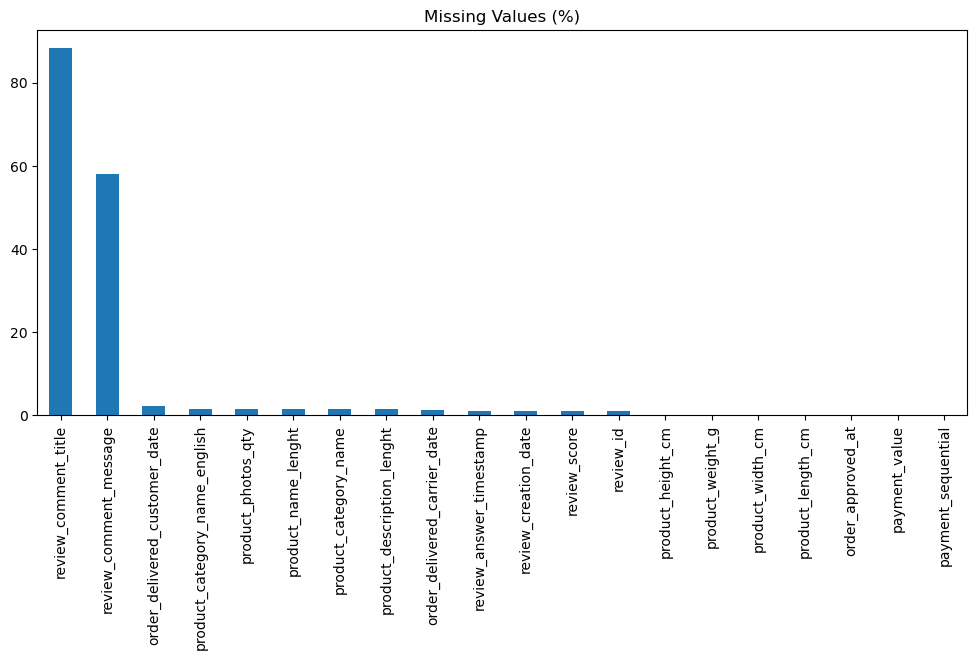

In [22]:
missing_percent.head(20).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Missing Values (%)")
plt.show()

In [23]:
master_df.duplicated().sum()

0

In [24]:
master_df = master_df.drop_duplicates()

In [25]:
master_df.dtypes

customer_id                       object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_id                          object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
product_category_name             object
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_c

In [26]:
date_columns = [

    "order_purchase_timestamp",

    "order_approved_at",

    "order_delivered_carrier_date",

    "order_delivered_customer_date",

    "order_estimated_delivery_date"

]

for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col])

In [27]:
master_df.to_csv(
    "../clean_dataset.csv",
    index=False
)

In [28]:
# Drop columns having too many missing values

master_df.drop(
    columns=[
        "review_comment_title",
        "review_comment_message"
    ],
    inplace=True
)

In [29]:
master_df.shape

(118310, 38)

In [30]:
num_cols = master_df.select_dtypes(include=["float64","int64"]).columns

master_df[num_cols] = master_df[num_cols].fillna(
    master_df[num_cols].median()
)

In [31]:
cat_cols = master_df.select_dtypes(include=["object"]).columns

master_df[cat_cols] = master_df[cat_cols].fillna("Unknown")

In [32]:
master_df.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2588
order_delivered_carrier_date     1254
order_approved_at                  15
review_id                           0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
customer_id                         0
product_photos_qty                  0
review_score                        0
review_creation_date                0
review_answer_timestamp             0
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
product_weight_g                    0
product_name_lenght                 0
product_description_lenght          0
order_estimated_delivery_date       0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_id    

In [33]:
master_df.to_csv(
    "cleaned_master_dataset.csv",
    index=False
)